# Lab 9 — Text Analysis with TextBlob
<hr style="border: 2px solid black;">
NLP basics: noun phrases, POS tagging, tokenization, lemmatization,
sentiment analysis, word frequency and word cloud.
<hr style="border: 2px solid black;">

In [1]:
# Install required packages (run once)
!pip install -q textblob wordcloud

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')
!python -m textblob.download_corpora


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package conll2000 to /root/nltk_data...
[nltk_data]   Unzipping corpora/conll2000.zip.
[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.
Finished.


## Noun Phrase Extraction
`blob.noun_phrases` returns a list of noun phrases detected in the text.

In [2]:
# EXAMPLE OF WHAT TEXT BLOB CAN DO:

from textblob import TextBlob

text = "TextBlob is a great Python library for NLP."
blob = TextBlob(text)
print(blob.noun_phrases)
# Output: WordList(['textblob', 'great python library', 'nlp'])


['textblob', 'python', 'nlp']


## Identifying Verbs and Nouns (POS Tagging)
`blob.tags` returns `(word, POS_tag)` pairs.
Common tags: NNP = proper noun, VBZ = verb 3rd person, JJ = adjective.

In [3]:
from textblob import TextBlob

text = "TextBlob makes NLP easy and fun."
blob = TextBlob(text)
print(blob.tags)
# Output: [('TextBlob', 'NNP'), ('makes', 'VBZ'), ('NLP', 'NNP'), ('easy', 'JJ'), ...]


[('TextBlob', 'NNP'), ('makes', 'VBZ'), ('NLP', 'NNP'), ('easy', 'JJ'), ('and', 'CC'), ('fun', 'NN')]


## Tokenize
`blob.words` gives word tokens; `blob.sentences` splits into sentences.

In [4]:
from textblob import TextBlob

text = "Hello world. TextBlob is cool. It splits sentences well."
blob = TextBlob(text)
print(blob.words)
# Output: WordList(['Hello', 'world', 'TextBlob', 'is', 'cool', 'It', 'splits', 'sentences', 'well'])
print(blob.sentences)
# Output: [Sentence("Hello world."), Sentence("TextBlob is cool."), ...]


['Hello', 'world', 'TextBlob', 'is', 'cool', 'It', 'splits', 'sentences', 'well']
[Sentence("Hello world."), Sentence("TextBlob is cool."), Sentence("It splits sentences well.")]


## Lemmatize
`Word.lemmatize()` reduces inflected forms to their base (lemma).

In [5]:
from textblob import TextBlob
from textblob.wordnet import VERB

word = TextBlob("running").words[0]
print(f"Plural of 'cat':              {TextBlob('cat').words[0].pluralize()}")
print(f"Lemma of 'running' (as verb): {word.lemmatize(VERB)}")
print(f"Lemma of 'mice':              {TextBlob('mice').words[0].lemmatize()}")
# Output:
# Plural of 'cat':              cats
# Lemma of 'running' (as verb): run
# Lemma of 'mice':              mouse


Plural of 'cat':              cats
Lemma of 'running' (as verb): run
Lemma of 'mice':              mouse


## Sentiment Analysis
`blob.sentiment.polarity` returns a score in `[-1, 1]`.
We compare TextBlob's automatic sentiment against the provided labels.

In [6]:
from textblob import TextBlob

reviews_with_sentiment = [
    ("This product is absolutely amazing! I love it so much.", "positive"),
    ("The features are fantastic and it works perfectly.", "positive"),
    ("I am extremely happy with this purchase. Highly recommended!", "positive"),
    ("What a terrible experience. The product broke after just one use.", "negative"),
    ("This is the worst item I have ever bought. Complete waste of money.", "negative"),
    ("I was so disappointed. It didn't meet my expectations at all.", "negative"),
    ("It's okay, but nothing special. Could be better.", "neutral"),
    ("Good value for the price. I'm satisfied.", "positive"),
    ("The customer service was awful and unhelpful.", "negative"),
    ("Really impressed with the quality and performance!", "positive"),
    ("Meh, it's alright. Not great, not bad.", "neutral"),
    ("Avoid this product at all costs! Seriously flawed.", "negative"),
    ("So glad I bought this! It has made my life easier.", "positive"),
    ("The setup was confusing and the instructions were unclear.", "negative"),
    ("A solid product that does exactly what it says.", "positive"),
]

print(f"{'Review Text':<70} | {'Provided':<12} | {'Polarity':>10} | {'TextBlob'}")
print("-" * 120)

for review_text, provided_sentiment in reviews_with_sentiment:
    blob     = TextBlob(review_text)
    polarity = blob.sentiment.polarity

    if polarity > 0.1:
        textblob_sentiment = "positive"
    elif polarity < -0.1:
        textblob_sentiment = "negative"
    else:
        textblob_sentiment = "neutral"

    print(f"{review_text:<70} | {provided_sentiment:<12} | {polarity:>10.2f} | {textblob_sentiment}")


Review Text                                                            | Provided     |   Polarity | TextBlob
------------------------------------------------------------------------------------------------------------------------
This product is absolutely amazing! I love it so much.                 | positive     |       0.48 | positive
The features are fantastic and it works perfectly.                     | positive     |       0.70 | positive
I am extremely happy with this purchase. Highly recommended!           | positive     |       0.50 | positive
What a terrible experience. The product broke after just one use.      | negative     |      -1.00 | negative
This is the worst item I have ever bought. Complete waste of money.    | negative     |      -0.37 | negative
I was so disappointed. It didn't meet my expectations at all.          | negative     |      -0.75 | negative
It's okay, but nothing special. Could be better.                       | neutral      |       0.45 | positive

## Words per Review

In [7]:
from textblob import TextBlob

print(f"{'Review Text':<70} | Words")
print("-" * 100)

for review_text, provided_sentiment in reviews_with_sentiment:
    blob = TextBlob(review_text)
    print(f"{review_text:<70} | {list(blob.words)}")


Review Text                                                            | Words
----------------------------------------------------------------------------------------------------
This product is absolutely amazing! I love it so much.                 | ['This', 'product', 'is', 'absolutely', 'amazing', 'I', 'love', 'it', 'so', 'much']
The features are fantastic and it works perfectly.                     | ['The', 'features', 'are', 'fantastic', 'and', 'it', 'works', 'perfectly']
I am extremely happy with this purchase. Highly recommended!           | ['I', 'am', 'extremely', 'happy', 'with', 'this', 'purchase', 'Highly', 'recommended']
What a terrible experience. The product broke after just one use.      | ['What', 'a', 'terrible', 'experience', 'The', 'product', 'broke', 'after', 'just', 'one', 'use']
This is the worst item I have ever bought. Complete waste of money.    | ['This', 'is', 'the', 'worst', 'item', 'I', 'have', 'ever', 'bought', 'Complete', 'waste', 'of', 'money']
I was

## Full Analysis: Sentiment Distribution, Word Frequency & Word Cloud
We combine sentiment analysis, lemmatization, stop-word removal,
frequency counting and a word cloud into one pipeline.

/tmp/ipykernel_174/463355730.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


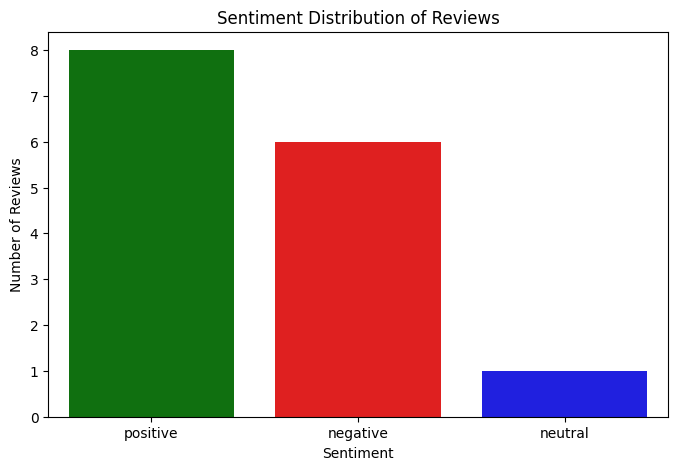

Sentiment Counts: Counter({'positive': 8, 'negative': 6, 'neutral': 1})
Polarity Scores:  [0.48, 0.7, 0.5, -1.0, -0.37, -0.75, 0.45, 0.6, -1.0, 1.0, -0.03, -0.5, 0.62, -0.3, 0.12]

Lemmatization complete.


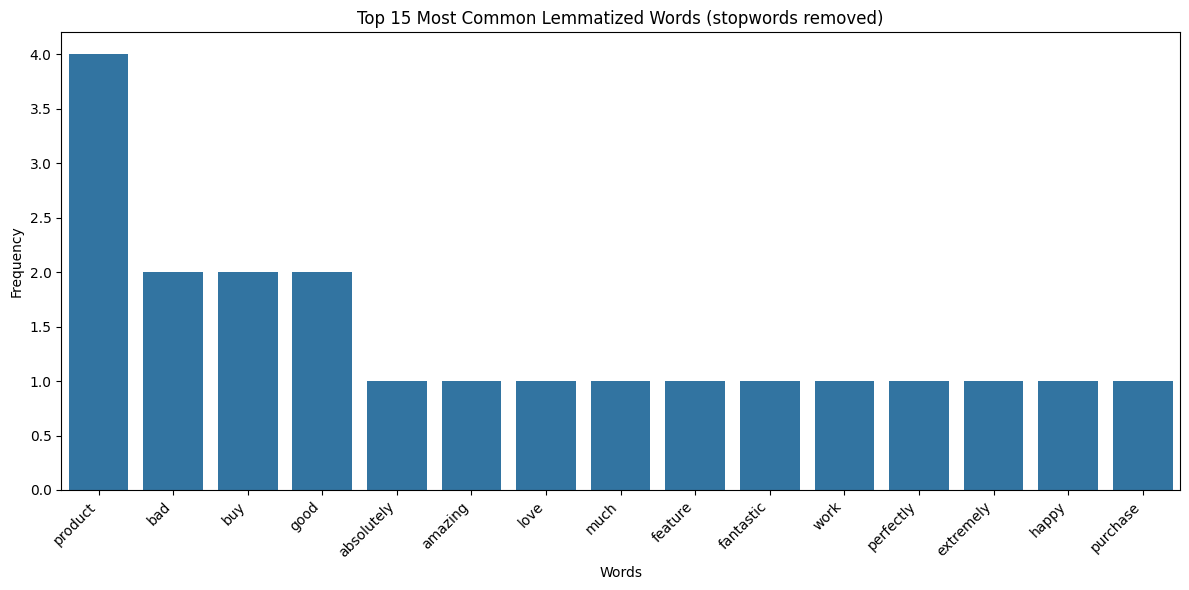

Most Common Words: [('product', 4), ('bad', 2), ('buy', 2), ('good', 2), ('absolutely', 1), ('amazing', 1), ('love', 1), ('much', 1), ('feature', 1), ('fantastic', 1), ('work', 1), ('perfectly', 1), ('extremely', 1), ('happy', 1), ('purchase', 1)]


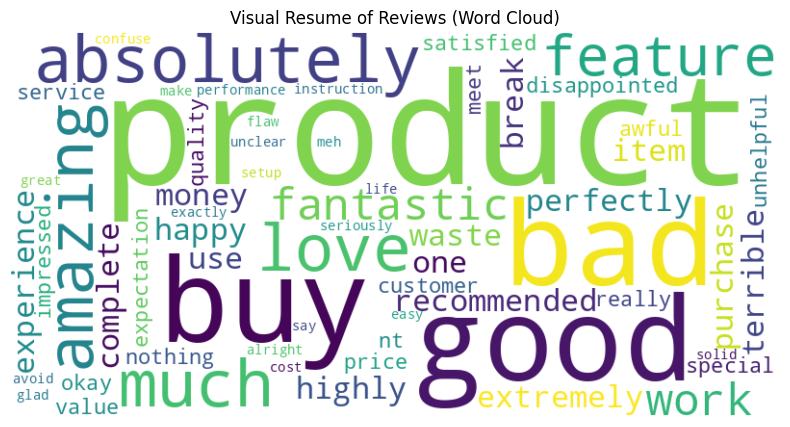

Word Cloud complete.


In [8]:
from textblob import TextBlob, Word
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from nltk.corpus import stopwords
import re

reviews_data = [
    ("This product is absolutely amazing! I love it so much.", "positive"),
    ("The features are fantastic and it works perfectly.", "positive"),
    ("I am extremely happy with this purchase. Highly recommended!", "positive"),
    ("What a terrible experience. The product broke after just one use.", "negative"),
    ("This is the worst item I have ever bought. Complete waste of money.", "negative"),
    ("I was so disappointed. It didn't meet my expectations at all.", "negative"),
    ("It's okay, but nothing special. Could be better.", "neutral"),
    ("Good value for the price. I'm satisfied.", "positive"),
    ("The customer service was awful and unhelpful.", "negative"),
    ("Really impressed with the quality and performance!", "positive"),
    ("Meh, it's alright. Not great, not bad.", "neutral"),
    ("Avoid this product at all costs! Seriously flawed.", "negative"),
    ("So glad I bought this! It has made my life easier.", "positive"),
    ("The setup was confusing and the instructions were unclear.", "negative"),
    ("A solid product that does exactly what it says.", "positive"),
]

reviews_text = [r[0] for r in reviews_data]

# --- 1. Sentiment Analysis and Visualization ---
sentiments      = []
polarity_scores = []

for review in reviews_text:
    blob = TextBlob(review)
    polarity_scores.append(blob.sentiment.polarity)
    if blob.sentiment.polarity > 0.1:
        sentiments.append("positive")
    elif blob.sentiment.polarity < -0.1:
        sentiments.append("negative")
    else:
        sentiments.append("neutral")

sentiment_counts = Counter(sentiments)

plt.figure(figsize=(8, 5))
sns.barplot(
    x=list(sentiment_counts.keys()),
    y=list(sentiment_counts.values()),
    palette=['green', 'red', 'blue']
)
plt.title('Sentiment Distribution of Reviews')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

print(f"Sentiment Counts: {sentiment_counts}")
print(f"Polarity Scores:  {[round(p, 2) for p in polarity_scores]}")

# --- 2. Lemmatization & Preprocessing ---
stop_words           = set(stopwords.words('english'))
all_lemmatized_words = []
full_lemmatized_text = ""

def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'): return 'a'
    if treebank_tag.startswith('V'): return 'v'
    if treebank_tag.startswith('N'): return 'n'
    if treebank_tag.startswith('R'): return 'r'
    return 'n'

for review in reviews_text:
    blob = TextBlob(review.lower())
    lemmatized_review_words = []
    for word, tag in blob.tags:
        word_cleaned = re.sub(r'[^\w\s]', '', str(word))
        word_cleaned = re.sub(r'\d+', '', word_cleaned).strip()
        if word_cleaned and word_cleaned not in stop_words and len(word_cleaned) > 1:
            lemma = Word(word_cleaned).lemmatize(get_wordnet_pos(tag))
            all_lemmatized_words.append(lemma)
            lemmatized_review_words.append(lemma)
    full_lemmatized_text += " ".join(lemmatized_review_words) + " "

print("\nLemmatization complete.")

# --- 3. Word Frequency Bar Chart ---
word_counts       = Counter(all_lemmatized_words)
most_common_words = word_counts.most_common(15)
words, counts     = zip(*most_common_words)

plt.figure(figsize=(12, 6))
sns.barplot(x=list(words), y=list(counts))
plt.title('Top 15 Most Common Lemmatized Words (stopwords removed)')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"Most Common Words: {most_common_words}")

# --- 4. Word Cloud ---
if full_lemmatized_text.strip():
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(full_lemmatized_text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Visual Resume of Reviews (Word Cloud)')
    plt.show()
    print("Word Cloud complete.")
else:
    print("No words left after preprocessing — cannot generate word cloud.")
